Python EDA (Retail Profit Leakage Analysis)

In [2]:
#Importing Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [3]:
df=pd.read_csv("../../dataset/Clean_superstore.csv")
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156  2016-11-08  2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156  2016-11-08  2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688  2016-06-12  2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966  2015-10-11  2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966  2015-10-11  2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...     Sales  \
0      Claire Gute   Consumer  United States        Henderson  ...  261.9600   
1      Claire Gute   Consumer  United States        Henderson  ...  731.9400   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   14.6200   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...  957.5775   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   22.3680   

   Quantity Discount    Profit P

Total Business Overview

In [4]:
#Total Sales and Profit
print(df["Sales"].sum())
print(df["Profit"].sum())
#Average Profit Margin
avg_profit = df["Profit Margin"].mean()
print("Average Profit Margin:", avg_profit)

2297200.8603000003
286397.0217
Average Profit Margin: 0.12031392972104457


Sales By Category

In [5]:
sales_by_category=df.groupby("Category")["Sales"].sum()
print(sales_by_category)

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


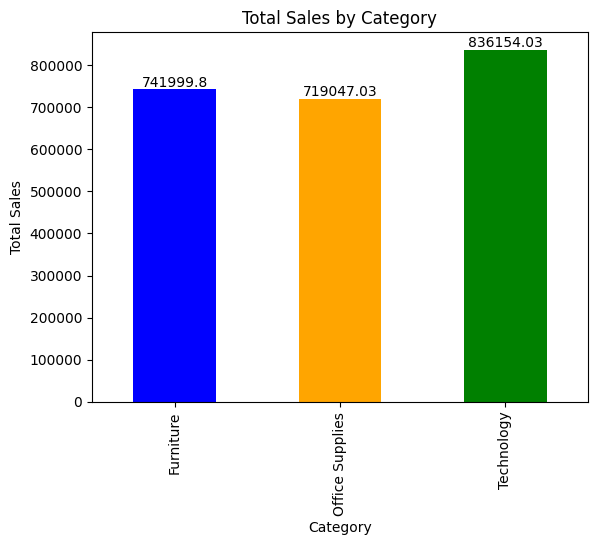

In [6]:
ax=sales_by_category.plot(kind="bar", color=["blue", "orange", "green"])
for i,v in enumerate(sales_by_category):
    ax.text(i,v,str(round(v,2)),ha="center", va="bottom")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()



Profit by Category

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64


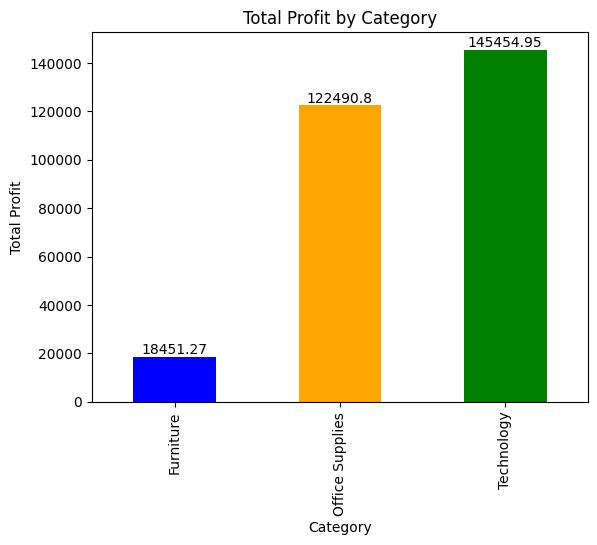

In [7]:
profit_by_category=df.groupby("Category")["Profit"].sum()
print(profit_by_category)
ax=profit_by_category.plot(kind="bar", color=["blue", "orange", "green"])
for i,v in enumerate(profit_by_category):
    ax.text(i,v,str(round(v,2)),ha="center", va="bottom")       
plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.show()      


Profit By Sub-Category

In [8]:
Profit_by_sub_category=df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False)
print(Profit_by_sub_category)

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64


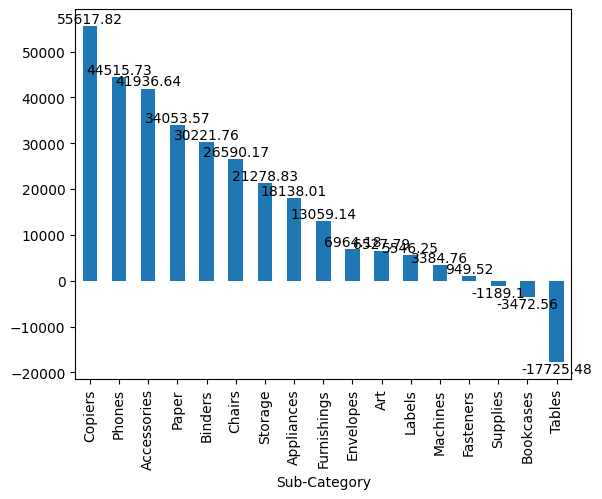

In [9]:
ax=Profit_by_sub_category.plot(kind="bar")
for i,v in enumerate(Profit_by_sub_category):
    va="bottom" if v>=0 else "top"
    ax.text(i,v,str(round(v,2)),ha="center",va=va)


Sales Trend Analysis

In [10]:
Monthly_sales=df.groupby("Month")["Sales"].sum()
print(Monthly_sales)

Month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64


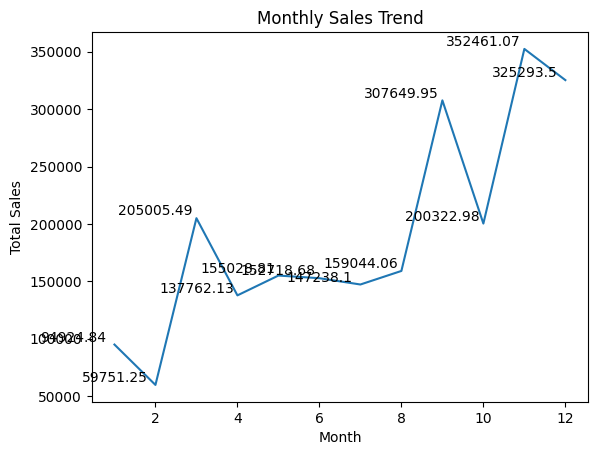

In [11]:
ax=Monthly_sales.plot(kind="line")
for i,v in enumerate(Monthly_sales):
    ax.text(i,v,str(round(v,2)),ha="center",va="bottom")
ax.set_title("Monthly Sales Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Total Sales")
plt.show()


Profit By Region

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64


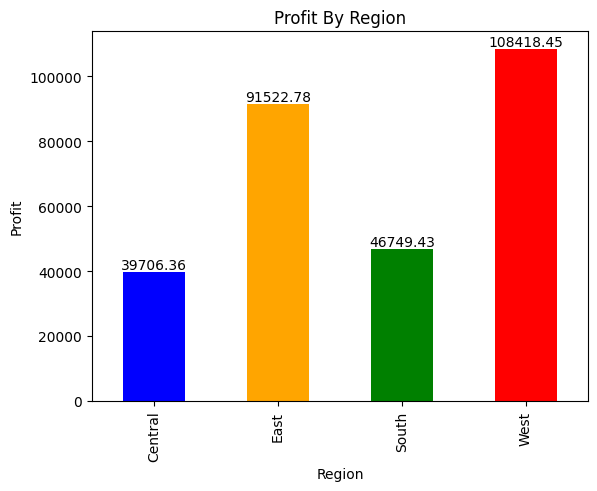

In [12]:
Profit_region=df.groupby("Region")["Profit"].sum()
print(Profit_region)
ax=Profit_region.plot(kind="bar",color=["blue","orange","green","red"])
for i,v in enumerate(Profit_region):
    ax.text(i,v,str(round(v,2)),ha="center",va="bottom")
    va="bottom" if v>=0 else "top"
ax.set_title("Profit By Region")
ax.set_xlabel("Region")
ax.set_ylabel("Profit")
plt.show()

Discount VS Profit Analysis

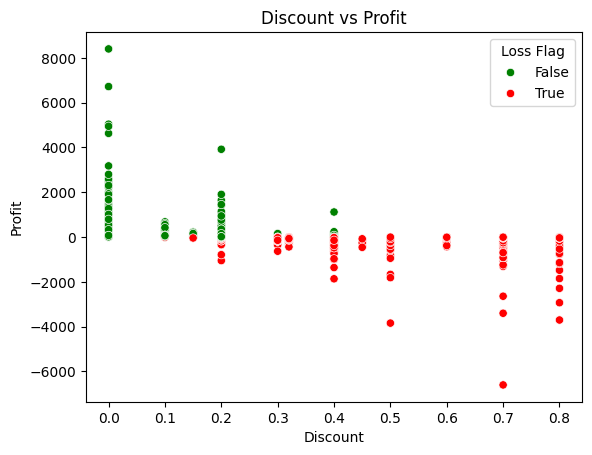

(1871, 27)
                                         Product Name      Sales     Profit
3       Bretford CR4500 Series Slim Rectangular Table   957.5775  -383.0310
14  Holmes Replacement Filter for HEPA Air Cleaner...    68.8100  -123.8580
15   Storex DuraTech Recycled Plastic Frosted Binders     2.5440    -3.8160
23                 Global Deluxe Stacking Chair, Gray    71.3720    -1.0196
27  Riverside Palais Royal Lawyers Bookcase, Royal...  3083.4300 -1665.0522


In [13]:
sns.scatterplot(x="Discount",y="Profit",
                hue="Loss Flag",
                palette={False:"green",True:"red"},
                data=df)
plt.title("Discount vs Profit")
plt.show()
#Loss making Orders
print(df[df["Profit"]<0].shape)
#Top loss products
print(df[df["Profit"]<0][["Product Name" , "Sales" , "Profit"]].head())

Correlation Heatmap

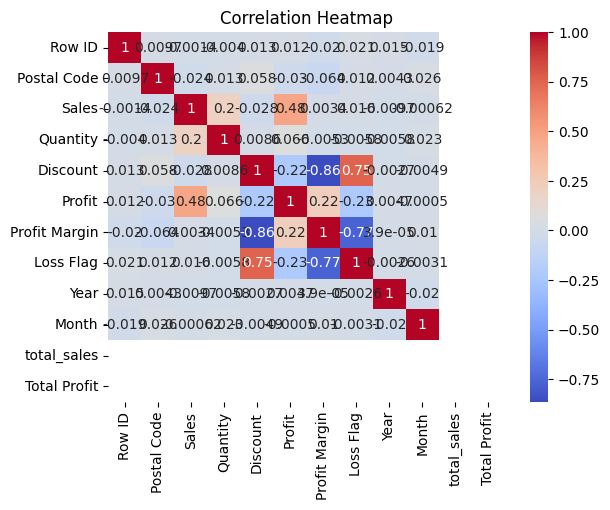

In [14]:
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Profit Distribution

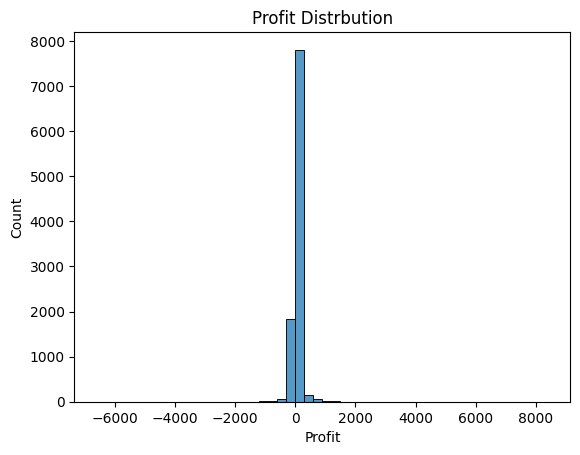

In [15]:
sns.histplot(df["Profit"] , bins=50)
plt.title("Profit Distrbution")
plt.show()
